In [1]:
! pip install git+https://github.com/amazon-science/chronos-forecasting.git

  Cloning https://github.com/amazon-science/chronos-forecasting.git to /private/var/folders/ck/9102qxqx7cb0nzwzg4my5wh00000gn/T/pip-req-build-6clstvst
  Running command git clone --filter=blob:none --quiet https://github.com/amazon-science/chronos-forecasting.git /private/var/folders/ck/9102qxqx7cb0nzwzg4my5wh00000gn/T/pip-req-build-6clstvst
  Resolved https://github.com/amazon-science/chronos-forecasting.git to commit 6d68ed7c4ed2805d122d77b4660765b4089de5ca
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


RMSE:       205.78
MAPE:       1.64%
Pearson R²: 0.0130


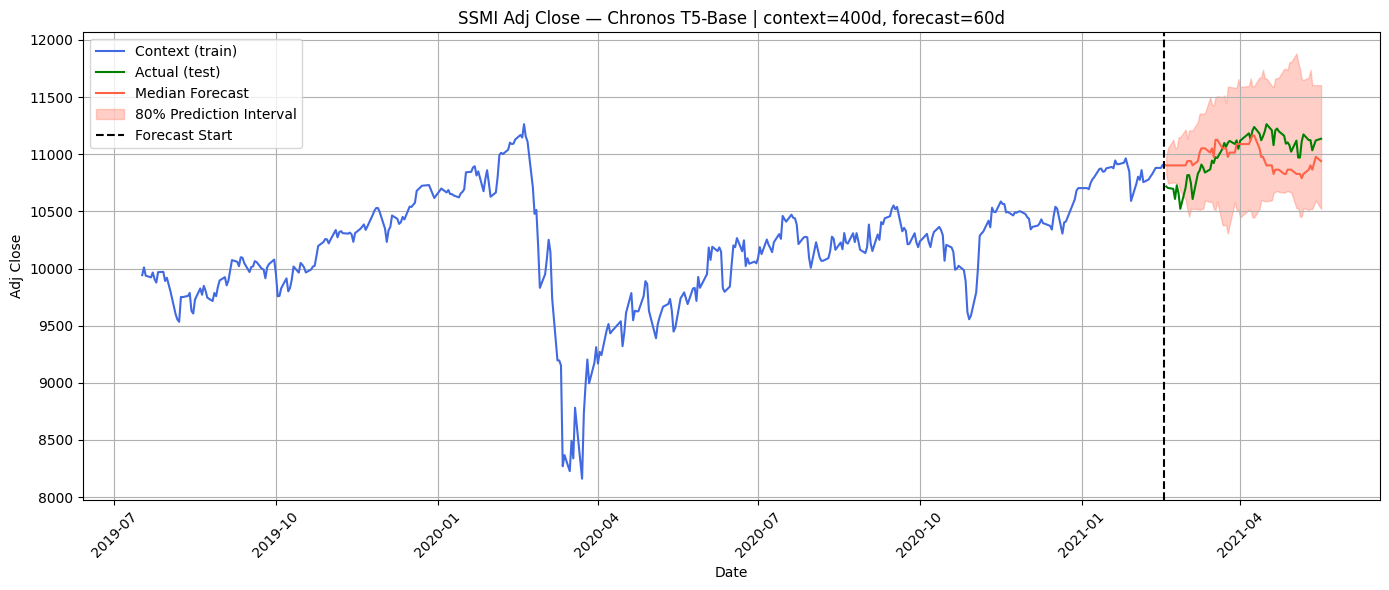

In [10]:
import numpy as np
import pandas as pd
import torch
from chronos import ChronosPipeline
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from scipy.stats import pearsonr

# the data
df = pd.read_csv("/Users/ismaelbrahimbelhaouari/Documents/St Gallen University /Deep Learning/DLSuperSlay/DataSets/SSMI cleaned/SSMI_cleaned.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# Control window size
context_length    = 400
prediction_length = 60

total_window = context_length + prediction_length
df_window = df.tail(total_window).reset_index(drop=True)

y = df_window["Adj Close"].values.astype(float)

y_train = torch.tensor(y[:context_length], dtype=torch.float32)
y_test  = torch.tensor(y[context_length:], dtype=torch.float32)

# Load Chronos
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-base",
    device_map="cpu",
    torch_dtype=torch.float32,
)

# Forecast
forecast = pipeline.predict(
    y_train,
    prediction_length=prediction_length,
    num_samples=20,
)

# Metrics
median_forecast = np.median(forecast[0].numpy(), axis=0)

rmse = np.sqrt(mean_squared_error(y_test.numpy(), median_forecast))
mape = mean_absolute_percentage_error(y_test.numpy(), median_forecast) * 100
pearson_r2 = pearsonr(y_test.numpy(), median_forecast).statistic ** 2

print(f"RMSE:       {rmse:.2f}")
print(f"MAPE:       {mape:.2f}%")
print(f"Pearson R²: {pearson_r2:.4f}")

# Plot
dates      = df_window["Date"].values
test_dates = dates[context_length:context_length + prediction_length]

low, median, high = np.quantile(forecast[0].numpy(), [0.1, 0.5, 0.9], axis=0)

plt.figure(figsize=(14, 6))
plt.plot(dates[:context_length], y[:context_length], color="royalblue", label="Context (train)")
plt.plot(dates[context_length:], y[context_length:], color="green",     label="Actual (test)")
plt.plot(test_dates, median,                          color="tomato",    label="Median Forecast")
plt.fill_between(test_dates, low, high, color="tomato", alpha=0.3,       label="80% Prediction Interval")
plt.axvline(x=dates[context_length - 1], color="black", linestyle="--", label="Forecast Start")

plt.legend()
plt.grid()
plt.xlabel("Date")
plt.ylabel("Adj Close")
plt.title(f"SSMI Adj Close — Chronos T5-Base | context={context_length}d, forecast={prediction_length}d")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Experiments:
#### I will divide the data in segements each segment will be forecasted, each forecast will give a 
- #### RMSE,
- #### MAPE 
- #### R^2 value.
#### This will then be summarised using a box plot. 

Segment 1/32 — RMSE: 66.07 | MAPE: 3.40% | R²: 0.7371
Segment 2/32 — RMSE: 58.67 | MAPE: 2.79% | R²: 0.0011
Segment 3/32 — RMSE: 43.68 | MAPE: 1.49% | R²: 0.1722
Segment 4/32 — RMSE: 150.82 | MAPE: 4.51% | R²: 0.4513
Segment 5/32 — RMSE: 162.75 | MAPE: 5.18% | R²: 0.0118
Segment 6/32 — RMSE: 45.53 | MAPE: 1.06% | R²: 0.0059
Segment 7/32 — RMSE: 105.08 | MAPE: 1.88% | R²: 0.0070
Segment 8/32 — RMSE: 489.90 | MAPE: 6.13% | R²: 0.0381
Segment 9/32 — RMSE: 374.79 | MAPE: 4.00% | R²: 0.0247
Segment 10/32 — RMSE: 97.85 | MAPE: 1.02% | R²: 0.0510
Segment 11/32 — RMSE: 171.30 | MAPE: 1.86% | R²: 0.8739
Segment 12/32 — RMSE: 339.77 | MAPE: 4.19% | R²: 0.0766
Segment 13/32 — RMSE: 280.63 | MAPE: 4.77% | R²: 0.2323
Segment 14/32 — RMSE: 66.61 | MAPE: 1.13% | R²: 0.6509
Segment 15/32 — RMSE: 193.73 | MAPE: 2.90% | R²: 0.4546
Segment 16/32 — RMSE: 214.32 | MAPE: 2.97% | R²: 0.4029
Segment 17/32 — RMSE: 94.34 | MAPE: 0.93% | R²: 0.0154
Segment 18/32 — RMSE: 117.63 | MAPE: 1.06% | R²: 0.4708
Segment 

/var/folders/ck/9102qxqx7cb0nzwzg4my5wh00000gn/T/ipykernel_28911/4185199907.py:113: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(metrics.values(), labels=metrics.keys(), showfliers=False)


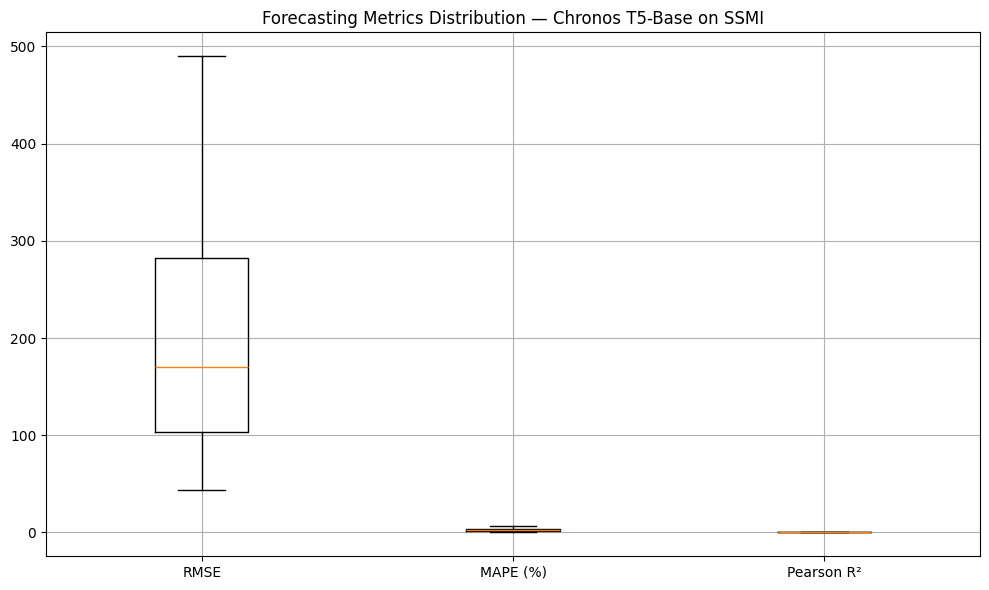

In [11]:
import numpy as np
import pandas as pd
import torch
from chronos import ChronosPipeline
import matplotlib.pyplot as plt
import logging
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from scipy.stats import pearsonr

logging.basicConfig(
    filename='ChronosBase_SSMI_Metrics.log',
    level=logging.INFO,
    format='%(asctime)s %(levelname)s: %(message)s'
)

def main():
    try:
        # ========================
        # 1) Load SSMI data
        # ========================
        df = pd.read_csv("/Users/ismaelbrahimbelhaouari/Documents/St Gallen University /Deep Learning/DLSuperSlay/DataSets/SSMI cleaned/SSMI_cleaned.csv", parse_dates=["Date"])
        df = df.sort_values("Date").reset_index(drop=True)

        y = df["Adj Close"].values.astype(float)
        total_samples = len(y)
        logging.info(f"Total SSMI samples loaded: {total_samples}")

        # ========================
        # 2) Sliding window config
        # ========================
        context_window   = 200
        forecast_horizon = 30
        step_size        = context_window + forecast_horizon
        num_segments     = (total_samples - context_window) // step_size

        logging.info(f"Segments to evaluate: {num_segments}")

        # ========================
        # 3) Load Chronos
        # ========================
        pipeline = ChronosPipeline.from_pretrained(
            "amazon/chronos-t5-base",
            device_map="cpu",
            torch_dtype=torch.float32,
        )
        logging.info("Chronos T5-Base loaded successfully.")

        # ========================
        # 4) Sliding window loop
        # ========================
        rmse_list    = []
        mape_list    = []
        pearson_list = []

        for segment in range(num_segments):
            start_context = segment * step_size
            end_context   = start_context + context_window
            if end_context + forecast_horizon > total_samples:
                break

            context     = torch.tensor(y[start_context:end_context], dtype=torch.float32)
            true_values = y[end_context:end_context + forecast_horizon]

            forecast_output = pipeline.predict(
                context,
                prediction_length=forecast_horizon,
                num_samples=20,
            )

            median_forecast = np.median(forecast_output[0].numpy(), axis=0)

            rmse       = np.sqrt(mean_squared_error(true_values, median_forecast))
            mape       = mean_absolute_percentage_error(true_values, median_forecast) * 100
            pearson_r2 = pearsonr(true_values, median_forecast).statistic ** 2

            rmse_list.append(rmse)
            mape_list.append(mape)
            pearson_list.append(pearson_r2)

            logging.info(f"Segment {segment+1}/{num_segments}: RMSE={rmse:.4f}, MAPE={mape:.4f}%, Pearson R²={pearson_r2:.4f}")
            print(f"Segment {segment+1}/{num_segments} — RMSE: {rmse:.2f} | MAPE: {mape:.2f}% | R²: {pearson_r2:.4f}")

        # ========================
        # 5) Save results
        # ========================
        np.savez_compressed("ChronosBase_SSMI_Metrics.npz",
                            rmse=np.array(rmse_list),
                            mape=np.array(mape_list),
                            pearson_coefficients=np.array(pearson_list),
                            context_window=context_window,
                            forecast_horizon=forecast_horizon,
                            num_segments=num_segments)
        logging.info("Results saved to ChronosBase_SSMI_Metrics.npz")

        # ========================
        # 6) Summary metrics
        # ========================
        print("\n--- Median Metrics for Chronos T5-Base on SSMI ---")
        print(f"Median RMSE:       {np.median(rmse_list):.4f}")
        print(f"Median MAPE:       {np.median(mape_list):.4f}%")
        print(f"Median Pearson R²: {np.median(pearson_list):.4f}")

        # ========================
        # 7) Box plots
        # ========================
        metrics = {
            "RMSE":       rmse_list,
            "MAPE (%)":   mape_list,
            "Pearson R²": pearson_list,
        }

        plt.figure(figsize=(10, 6))
        plt.boxplot(metrics.values(), labels=metrics.keys(), showfliers=False)
        plt.title("Forecasting Metrics Distribution — Chronos T5-Base on SSMI")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        logging.error("An error occurred.", exc_info=True)
        print("An error occurred. Check ChronosBase_SSMI_Metrics.log for details.")
        try:
            np.savez_compressed("partial_ChronosBase_SSMI_Metrics.npz",
                                rmse=np.array(rmse_list) if 'rmse_list' in locals() else None,
                                mape=np.array(mape_list) if 'mape_list' in locals() else None,
                                pearson_coefficients=np.array(pearson_list) if 'pearson_list' in locals() else None)
        except Exception as save_exception:
            logging.error("Failed to save partial results.", exc_info=True)
    finally:
        logging.info("Forecasting run completed.")

if __name__ == '__main__':
    main()

In [12]:
import numpy as np

data = np.load("ChronosBase_SSMI_Metrics.npz")

print("--- Median Metrics for Chronos T5-Base on SSMI ---")
print(f"Median RMSE:       {np.median(data['rmse']):.4f}")
print(f"Median MAPE:       {np.median(data['mape']):.4f}%")
print(f"Median Pearson R²: {np.median(data['pearson_coefficients']):.4f}")

--- Median Metrics for Chronos T5-Base on SSMI ---
Median RMSE:       169.8912
Median MAPE:       2.7416%
Median Pearson R²: 0.1155
